# **Lab: Model Interpretation**


## Exercise 3: Xgboost with Hyperopt

We will explore Hyperopt for automatic hyperparameter tuning with Xgboost.

The steps are:
1.   Create new Git branch
2.   Load the dataset
3.   Hyperparameter tuning with Hyperopt
4.   Push changes


### 1.   Create new Git branch


**[1.1]** Create a new git branch called `adv_mla_5_hyperopt`


In [ ]:
# Placeholder for student's code (command line)

In [ ]:
# Solution:
git checkout -b adv_mla_5_hyperopt

**[1.2]** Launch Jupyter Lab from your virtual environment

In [ ]:
# Placeholder for student's code (command line)

In [ ]:
# Solution:
poetry run jupyter lab

**[1.3]** Navigate the folder `notebooks` and create a new jupyter notebook called `3_hyperopt.ipynb`

### 2. Load the dataset

**[2.1]** Launch magic commands to automatically reload modules

In [ ]:
# Placeholder for student's code (command line)

In [1]:
# Solution
%load_ext autoreload
%autoreload 2

**[2.2]** Import the pandas, numpy packages and dump from joblib

In [2]:
# Placeholder for student's code (command line)

In [3]:
# Solution
import pandas as pd
import numpy as np
from joblib import dump

**[2.3]** Import the `load_sets()` function from your custom package

In [ ]:
# Placeholder for student's code (command line)

In [4]:
# Solution
from my_krml_studentid.data.sets import load_sets

**[2.4]** Load the saved sets from `data/processed`

In [5]:
# Placeholder for student's code (command line)

In [6]:
# Solution
X_train, y_train, X_val, y_val, X_test, y_test = load_sets(path='../data/processed/')

### 3. Hyperparameter tuning with Hyperopt

**[3.1]** IMport xgboost

In [7]:
# Placeholder for student's code (command line)

In [8]:
# Solution:
import xgboost as xgb

**[3.2]** Import Trials, STATUS_OK, tpe, hp, fmin from hyperopt package

In [9]:
# Placeholder for student's code (Python code)

In [10]:
# Solution:
from hyperopt import Trials, STATUS_OK, tpe, hp, fmin
rstate = np.random.default_rng(42)

**[3.3]** Define the search space for xgboost hyperparameters

In [11]:
space = {
    'max_depth' : hp.choice('max_depth', range(3, 15, 1)),
    'min_child_weight' : hp.choice('min_child_weight', range(3, 15, 1)),
    'learning_rate' : hp.quniform('learning_rate', 0.01, 0.4, 0.05),
    'subsample' : hp.quniform('subsample', 0.7, 1, 0.05),
    'colsample_bytree' : hp.quniform('colsample_bytree', 0.2, 0.5, 0.05)
}

**[3.4]** Define a function called `objective` with the following logics:
- input parameters: hyperparameter seacrh space (`space`)
- logics: train a xgboost model with the search space and calculate the average accuracy score for cross validation with 5 folds
- output parameters: dictionary with the loss score and STATUS_OK

In [12]:
# Placeholder for student's code (Python code)

In [13]:
# Solution:
def objective(space):
    from sklearn.model_selection import cross_val_score

    xgboost = xgb.XGBClassifier(
        max_depth = int(space['max_depth']),
        learning_rate = space['learning_rate'],
        min_child_weight = space['min_child_weight'],
        subsample = space['subsample'],
        colsample_bytree = space['colsample_bytree']
    )

    acc = cross_val_score(xgboost, X_train, y_train, cv=5, scoring="accuracy").mean()

    return{'loss': 1-acc, 'status': STATUS_OK }

**[3.5]** Launch Hyperopt search and save the result in a variable called `best`

In [14]:
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=3,
    rstate=rstate
)

100%|██████████| 3/3 [00:30<00:00, 10.14s/trial, best loss: 0.09929619384432231]


**[3.6]** Print the best set of hyperparameters

In [15]:
# Placeholder for student's code (Python code)

In [16]:
# Solution:
print("Best: ", best)

Best:  {'colsample_bytree': np.float64(0.4), 'learning_rate': np.float64(0.35000000000000003), 'max_depth': np.int64(7), 'min_child_weight': np.int64(7), 'subsample': np.float64(0.9500000000000001)}


**[3.7]** Instantiate a XGBClassifier with best set of hyperparameters

In [17]:
# Placeholder for student's code (Python code)

In [18]:
# Solution:
xgboost2 = xgb.XGBClassifier(
    max_depth = best['max_depth'],
    learning_rate = best['learning_rate'],
    min_child_weight = best['min_child_weight'],
    subsample = best['subsample'],
    colsample_bytree = best['colsample_bytree']
)

**[3.8]** Fit the model and display its performance on the training and validation sets

In [19]:
# Placeholder for student's code (Python code)

In [21]:
# Solution:
from my_krml_studentid.models.performance import fit_assess_classifier

xgboost2 = fit_assess_classifier(xgboost2, X_train, y_train, X_val, y_val)

Accuracy Training: 0.9245841941244441
F1 Training: 0.9243054549749032
Accuracy Validation: 0.903821508855228
F1 Validation: 0.9033933941421698


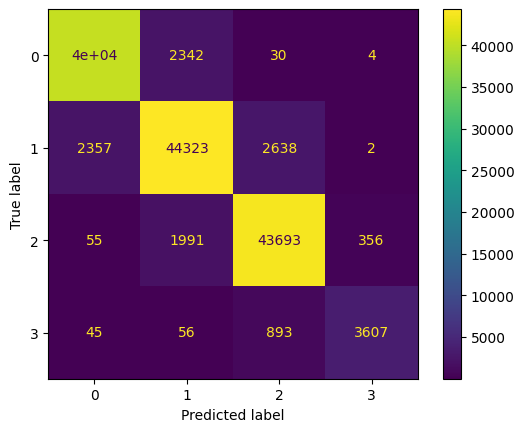

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_predst = xgboost2.predict(X_train)
cm = confusion_matrix(y_train, y_predst, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0, 1, 2, 3])
disp.plot()
plt.show()

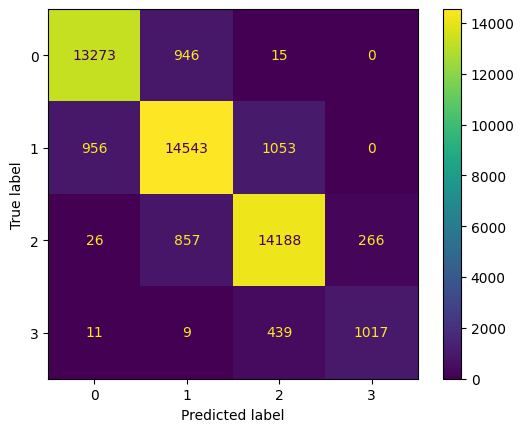

In [24]:
y_predsv = xgboost2.predict(X_val)
cm = confusion_matrix(y_val, y_predsv, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0, 1, 2, 3])
disp.plot()
plt.show()

**[3.9]** Save the fitted model into the folder models as a file called `xgboost_best`

In [ ]:
# Placeholder for student's code (Python code)

In [25]:
# Solution:
dump(xgboost2,  '../models/xgboost_best.joblib')

['../models/xgboost_best.joblib']

# 4.   Push changes

**[4.1]** Add you changes to git staging area

In [ ]:
# Placeholder for student's code (command line)

In [ ]:
# Solution:
git add .

**[4.2]** Create the snapshot of your repository and add a description

In [ ]:
# Placeholder for student's code (command line)

In [ ]:
# Solution:
git commit -m "xgboost hyperopt"

**[4.3]** Push your snapshot to Github


In [ ]:
# Placeholder for student's code (command line)

In [ ]:
# Solution:
git push

**[4.4]** Go to Github and merge the branch after reviewing the code and fixing any conflict




**[4.5]** Check out to the master branch

In [ ]:
# Placeholder for student's code (command line)

In [ ]:
# Solution:
git checkout master

**[4.6]** Pull the latest updates

In [ ]:
# Placeholder for student's code (command line)

In [ ]:
# Solution
git pull